In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("teen_phone_addiction_dataset.csv")

df.head()

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


In [3]:
print("Pearson Correlation:")
print(df.corr(numeric_only=True, method="pearson"))

print("\nSpearman Correlation:")
print(df.corr(numeric_only=True, method="spearman"))

Pearson Correlation:
                              ID       Age  Daily_Usage_Hours  Sleep_Hours  \
ID                      1.000000 -0.035674          -0.004700     0.018254   
Age                    -0.035674  1.000000           0.040689     0.014725   
Daily_Usage_Hours      -0.004700  0.040689           1.000000     0.016444   
Sleep_Hours             0.018254  0.014725           0.016444     1.000000   
Academic_Performance   -0.013589  0.023481           0.021345    -0.000273   
Social_Interactions    -0.041130 -0.020240          -0.030383    -0.017898   
Exercise_Hours          0.001156  0.001187          -0.005930     0.006814   
Anxiety_Level           0.008810  0.014651          -0.007221     0.009836   
Depression_Level        0.004777  0.052699           0.009672    -0.011518   
Self_Esteem            -0.006017 -0.033177           0.006340     0.016488   
Parental_Control       -0.024219  0.028212           0.000970     0.005670   
Screen_Time_Before_Bed  0.004300  0.007213 

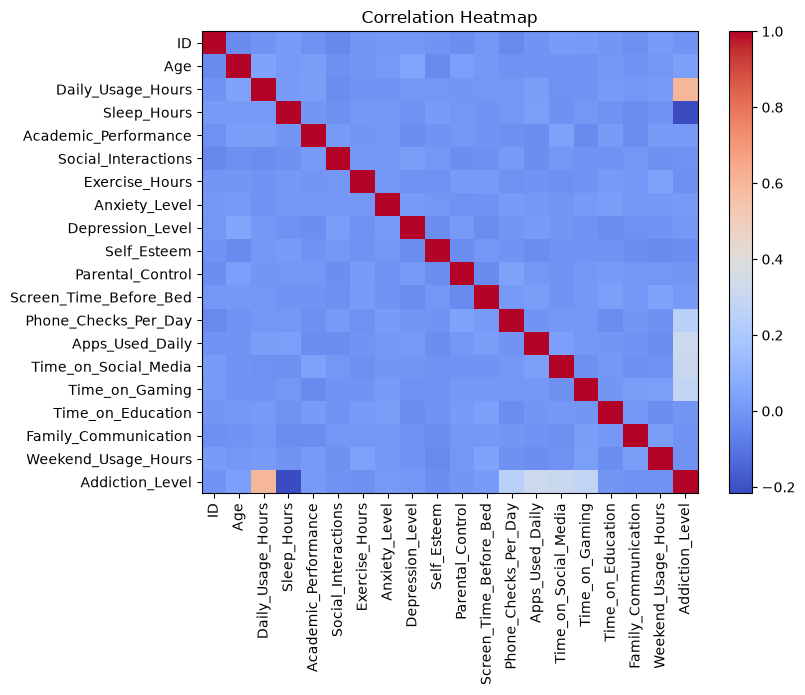

In [4]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.show()

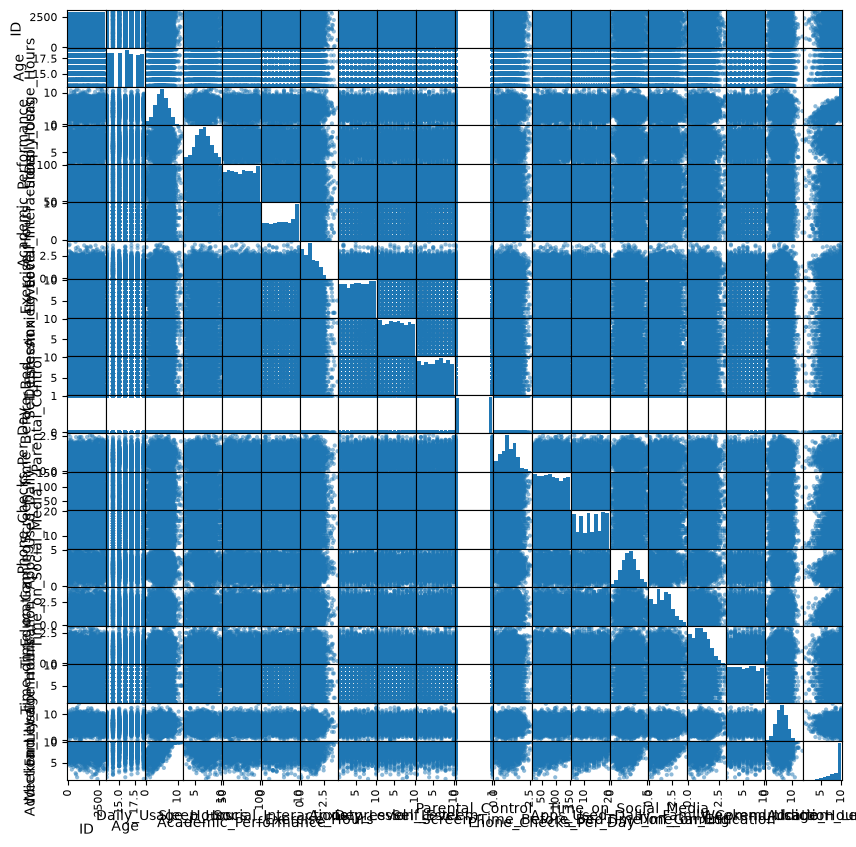

In [5]:
from pandas.plotting import scatter_matrix

scatter_matrix(df.select_dtypes(include=['number']), figsize=(10,10))
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['Daily_Usage_Hours']]
y = df['Academic_Performance']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Model trained successfully!")

Model trained successfully!


In [7]:
print(df.columns)

Index(['ID', 'Name', 'Age', 'Gender', 'Location', 'School_Grade',
       'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance',
       'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level',
       'Depression_Level', 'Self_Esteem', 'Parental_Control',
       'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily',
       'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education',
       'Phone_Usage_Purpose', 'Family_Communication', 'Weekend_Usage_Hours',
       'Addiction_Level'],
      dtype='str')


In [9]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import math

print("R² Score:", r2_score(y_test, predictions))
print("MAE:", mean_absolute_error(y_test, predictions))
print("RMSE:", math.sqrt(mean_squared_error(y_test, predictions)))

R² Score: -0.0034961262256325565
MAE: 12.999931274048988
RMSE: 15.031924648853074


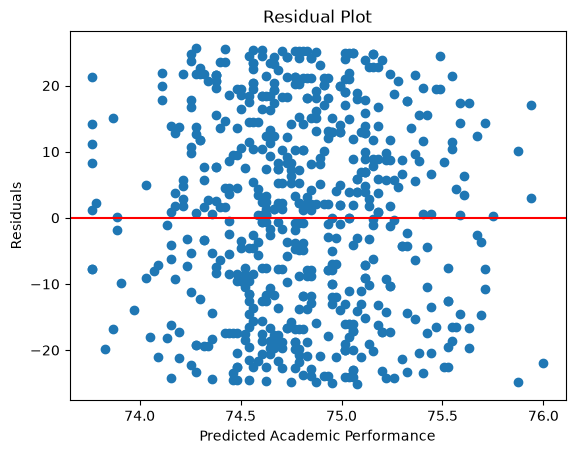

In [10]:
residuals = y_test - predictions

plt.scatter(predictions, residuals)
plt.axhline(y=0, color="red")

plt.xlabel("Predicted Academic Performance")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()